In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("train.csv")

In [3]:
data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [4]:
data["accident_risk"]= list(map(int,(data["accident_risk"]>=0.5)))

In [5]:
data

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,1


In [6]:
data = data.drop("id",axis=1)

In [7]:
data

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0
517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,1


In [8]:
num_cols = [col for col in data.drop("accident_risk",axis=1).columns if data[col].dtype!="object"]
obj_cols = [col for col in data.columns if data[col].dtype=="object"]

<Axes: >

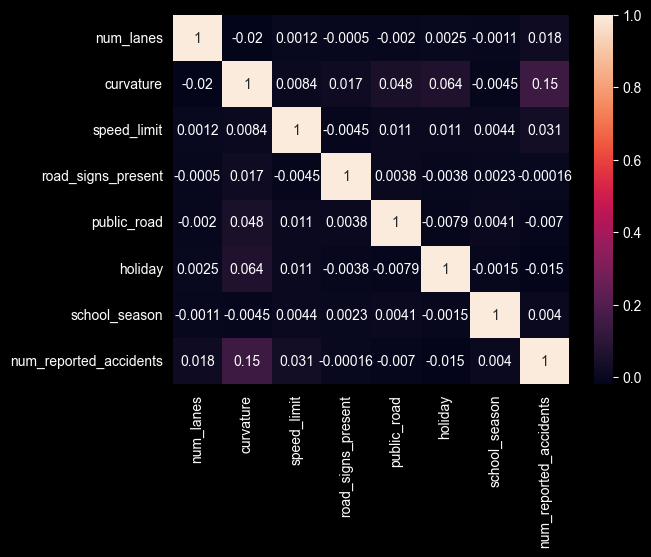

In [9]:
import seaborn as sns
sns.heatmap(data[num_cols].corr(),annot=True)

In [10]:
data = data.drop(["road_signs_present","school_season","public_road"],axis=1)

In [11]:
num_cols = [col for col in data.drop("accident_risk",axis=1).columns if data[col].dtype!="object"]
obj_cols = [col for col in data.columns if data[col].dtype=="object"]

<Axes: >

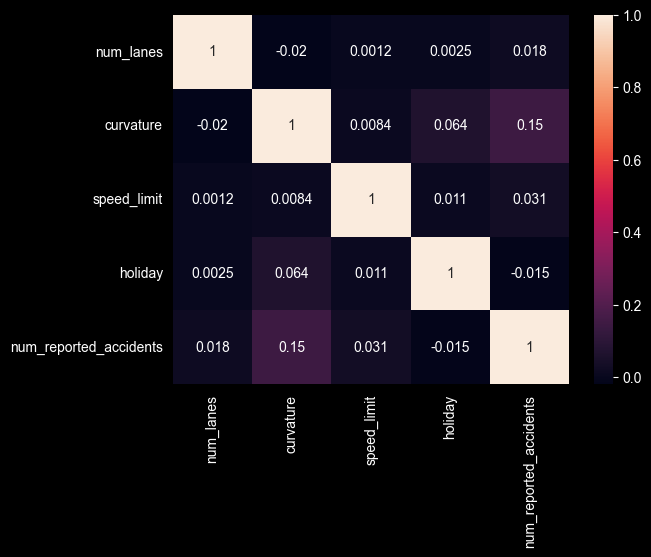

In [12]:
import seaborn as sns
sns.heatmap(data[num_cols].corr(),annot=True)

In [13]:
for col in obj_cols:
    print(f"{col} : {len(data[col].value_counts())}")

road_type : 3
lighting : 3
weather : 3
time_of_day : 3


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
obj_pipe = Pipeline([
    ("One Hot Encoder",OneHotEncoder(handle_unknown="ignore"))
])
num_pipe =Pipeline([
    ("Min max Scaler",MinMaxScaler())
])


In [15]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("Obj", obj_pipe,obj_cols),
    ("num",num_pipe,num_cols)
])
preprocessor

,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
lr_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("Logistic regressor",LogisticRegression(random_state=42))
])
dt_pipe = Pipeline([
    ("Preprocessor",preprocessor),
    ("decison tree classifier",DecisionTreeClassifier(random_state=42,max_depth=20))
])

In [17]:
lr_pipe

,steps,"[('Preprocessor', ...), ('Logistic regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
dt_pipe

,steps,"[('Preprocessor', ...), ('decison tree classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
from sklearn.model_selection import train_test_split
trainx,testx,trainy,testy = train_test_split(data.drop("accident_risk",axis=1),data["accident_risk"],test_size=0.2,random_state=42)

In [20]:
lr_pipe.fit(trainx,trainy)


,steps,"[('Preprocessor', ...), ('Logistic regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
dt_pipe.fit(trainx,trainy)

,steps,"[('Preprocessor', ...), ('decison tree classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Obj', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
lr_preds = lr_pipe.predict(testx)
dt_preds = dt_pipe.predict(testx)

Logistic Regression


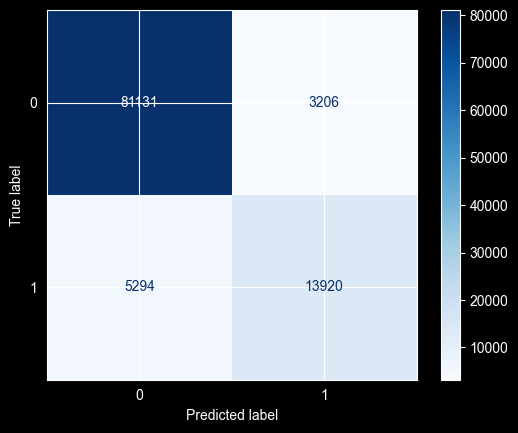

In [23]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(
    testy,
    lr_preds,
    cmap="Blues"
)

plt.show()

In [24]:
print(f"Logistic Regression: \n{classification_report(testy,lr_preds)}")

Logistic Regression: 
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     84337
           1       0.81      0.72      0.77     19214

    accuracy                           0.92    103551
   macro avg       0.88      0.84      0.86    103551
weighted avg       0.92      0.92      0.92    103551



Decision Tree


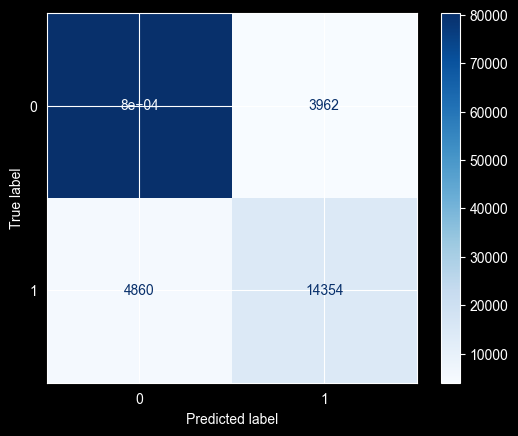

In [25]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
print("Decision Tree")
ConfusionMatrixDisplay.from_predictions(
    testy,
    dt_preds,
    cmap="Blues"
)
plt.show()

In [26]:
print(f"Decisiontree classifier: \n{classification_report(testy,dt_preds)}")

Decisiontree classifier: 
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     84337
           1       0.78      0.75      0.76     19214

    accuracy                           0.91    103551
   macro avg       0.86      0.85      0.86    103551
weighted avg       0.91      0.91      0.91    103551



In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,lr_preds)

0.9179148438933472

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(testy,dt_preds)

0.9148052650384835